# NB 22 - API model showcase  (`api/fast.py`)

This notebook loads **exactly the artefacts the FastAPI service uses**
(`load_model("pca")`, `load_scaler()`, `load_target_channels()`,
`PCA_THRESHOLD`) and runs `predict()` / `predict_report()` end-to-end on
the **`test_internal` slice**.

It then visualises the result the way you'd want for a stakeholder
walk-through - metrics, timeline, event analysis, per-channel diagnostics,
and a few extras that fall out of `predict_report` (top-N channels,
score distribution, confusion matrix).

> All numbers below match what `/predict` and `/report` would return on
> this slice if it were posted to the API.

## 1 - Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Same imports as api/fast.py
from sentinel.ml_logic.data      import load_target_channels, find_anomaly_segments
from sentinel.ml_logic.predictor import predict, predict_report
from sentinel.ml_logic.registry  import load_model, load_scaler
from sentinel.params             import PROCESSED_DIR, ANOMALY_COLOR, NOMINAL_COLOR#, PCA_THRESHOLD

PCA_THRESHOLD = 0.053293

# Metrics + viz helpers
from sentinel.ml_logic.metrics import event_f05, corrected_event_f05, row_precision_recall
from sentinel.ml_logic.viz     import (
    plot_timeline, plot_event_analysis,
    plot_score_distribution, plot_confusion_and_channel_errors,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print('PCA_THRESHOLD :', PCA_THRESHOLD)
print('PROCESSED_DIR :', PROCESSED_DIR)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PCA_THRESHOLD : 0.053293
PROCESSED_DIR : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed


## 2 - Load the API artefacts

Same four objects the FastAPI lifespan loads at startup.


In [36]:
model    = load_model('pca')
scaler   = load_scaler()
features = load_target_channels()

# # test_api slice (small demo slice)
X_int    = np.load(PROCESSED_DIR / 'test_api.npy')
y_int    = np.load(PROCESSED_DIR / 'y_test_api.npy')

# test_internal - whole internal test set from train/val/test_internal split (with labels)
#X_int    = np.load(PROCESSED_DIR / 'test_intern_raw.npy')
#y_int    = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'model     : {type(model).__name__}  (n_components={getattr(model, "n_components_", "?")})')
print(f'scaler    : {type(scaler).__name__}')
print(f'features  : {len(features)} channels  →  {features[:3]} ... {features[-3:]}')
print(f'X_int     : {X_int.shape}   {X_int.dtype}')
print(f'y_int     : {y_int.shape}   anomaly rows: {int(y_int.sum()):,} ({y_int.mean():.2%})')
print(f'threshold : {PCA_THRESHOLD}')


✅ Model loaded ← /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/pca.pkl
✅ Scaler loaded ← /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/scaler.pkl
model     : PCA  (n_components=38)
scaler    : RobustScaler
features  : 58 channels  →  ['channel_12', 'channel_13', 'channel_14'] ... ['channel_74', 'channel_75', 'channel_76']
X_int     : (150000, 58)   float32
y_int     : (150000,)   anomaly rows: 1,480 (0.99%)
threshold : 0.053293


## 3 - Run the API pipeline

`predict()` returns the `(id, is_anomaly)` table the `/predict` endpoint
serves; `predict_report()` (used by `/report`) additionally returns
`row_scores`, `per_channel_mse`, `window_channel_mse`, and `window_top_channels`.
We call both so the showcase plots have everything in hand.


In [37]:
t0 = time.time()
sub = predict(
    model=model, scaler=scaler, features=features,
    X_raw=X_int, threshold=PCA_THRESHOLD,
)
t_pred = time.time() - t0

# predict_report:
#   topk=None           -> PCA scoring (mean over all channels). Same rule
#                          as predict() so labels agree.
#   n_top_channels=6    -> diagnostic only; fills the output 'window_top_channels'

t0 = time.time()
rep = predict_report(
    model=model, scaler=scaler, features=features,
    X_raw=X_int, threshold=PCA_THRESHOLD,
    topk=None, n_top_channels=6,
)
t_rep = time.time() - t0

# Local names mirror the dict keys so it stays obvious where each piece comes from.
row_scores          = rep['row_scores']           # per-row reconstruction MSE
labels              = rep['labels']               # 0/1 predictions per row
per_channel_mse     = rep['per_channel_mse']      # mean MSE per channel across all windows
window_channel_mse  = rep['window_channel_mse']   # per-window per-channel MSE
window_top_channels = rep['window_top_channels']  # top-N channel indices per window

# Parity sanity-check: the /predict endpoint and our scores must agree.
assert np.array_equal(sub['is_anomaly'].values.astype(np.int8), labels), \
    'predict() and predict_report(topk=None) disagree - pipeline drift!'

print(f'predict()        : {t_pred:.2f}s   ->  {len(sub):,} rows')
print(f'predict_report() : {t_rep:.2f}s   ->  row_scores {row_scores.shape}, per_channel_mse {per_channel_mse.shape}')
print(f'predicted anom   : {int(labels.sum()):,} rows  ({labels.mean():.2%})')
print(f'score range      : [{row_scores.min():.4f}, {row_scores.max():.4f}]   mean {row_scores.mean():.4f}')
print(f'top-6 indices    : {window_top_channels.shape}')


predict()        : 0.06s   ->  150,000 rows
predict_report() : 0.05s   ->  row_scores (150000,), per_channel_mse (58,)
predicted anom   : 1,400 rows  (0.93%)
score range      : [0.0305, 0.0595]   mean 0.0377
top-6 indices    : (1500, 6)


In [38]:
# rep['window_top_channels']
window_top_channels

array([[57, 56, 53, 54, 52, 51],
       [57, 56, 54, 52, 53, 55],
       [57, 55, 56, 53, 51, 54],
       ...,
       [57, 55, 56, 54, 51, 53],
       [57, 56, 55, 54, 51, 53],
       [57, 56, 55, 54, 53, 51]])

In [39]:
# MSE for every channel averaged across all windows/rows
per_channel_mse

array([1.4585493e-03, 1.7863137e-03, 9.2259618e-03, 6.8700057e-04,
       3.5662198e-04, 3.4338629e-03, 4.8406678e-03, 6.1590336e-03,
       2.8968726e-03, 1.8803956e-02, 1.0224563e-03, 1.5530974e-03,
       4.4856986e-04, 2.2700015e-03, 2.4420947e-03, 4.0297457e-03,
       1.0723121e-03, 2.9036752e-03, 6.6966414e-02, 9.6923439e-04,
       4.4687095e-04, 7.0756994e-04, 9.1241370e-04, 2.4315424e-03,
       3.5672998e-03, 2.2438667e-03, 6.8153583e-02, 3.2026498e-03,
       6.9889514e-04, 2.4185266e-02, 6.4159334e-02, 2.2577399e-02,
       6.2625766e-02, 2.4922322e-02, 6.9087498e-02, 5.5747298e-03,
       7.0601776e-03, 5.9079533e-03, 5.7807644e-03, 7.0896880e-03,
       5.7285428e-03, 3.1470913e-03, 2.8650509e-03, 4.3209675e-03,
       2.9199333e-03, 4.4866384e-04, 4.9936428e-04, 6.3320785e-04,
       4.4282664e-10, 8.3982665e-10, 1.4687556e-02, 1.4872748e-01,
       1.2884718e-01, 1.5255970e-01, 1.5048760e-01, 1.7218548e-01,
       2.2548436e-01, 6.5712166e-01], dtype=float32)

In [40]:
head = sub.head(10).copy()
head['score']    = row_scores[:10].round(5)
head['gt_label'] = y_int[:10]
print(head.to_string(index=False))


 id  is_anomaly   score  gt_label
  0           0 0.03332         0
  1           0 0.03332         0
  2           0 0.03332         0
  3           0 0.03332         0
  4           0 0.03332         0
  5           0 0.03332         0
  6           0 0.03332         0
  7           0 0.03332         0
  8           0 0.03332         0
  9           0 0.03332         0


In [41]:
window_top_channels

array([[57, 56, 53, 54, 52, 51],
       [57, 56, 54, 52, 53, 55],
       [57, 55, 56, 53, 51, 54],
       ...,
       [57, 55, 56, 54, 51, 53],
       [57, 56, 55, 54, 51, 53],
       [57, 56, 55, 54, 53, 51]])

## 4 - Metrics

Threshold is fixed at `PCA_THRESHOLD` (the value the API uses); we don't
re-tune here. We compute the standard suite (event-wise, ESA-corrected,
row-level) and lay them out in a table plus a grouped bar chart so the
trade-offs are visible at a glance.


In [42]:
ef  = event_f05(y_int, labels)
esa = corrected_event_f05(y_int, labels)
rw  = row_precision_recall(y_int, labels)
n_ev_total = int(ef['tp_events'] + ef['fn_events'])
n_ev_hit   = int(ef['tp_events'])

m = {
    'event F0.5'      : ef['f_score'],
    'event precision' : ef['precision'],
    'event recall'    : ef['recall'],
    'ESA F0.5'        : esa['f_score'],
    'ESA Pr_ew'       : esa['precision'],
    'ESA TNR'         : esa['tnr'],
    'row F1'          : rw['f1'],
    'row precision'   : rw['precision'],
    'row recall'      : rw['recall'],
    'flag rate'       : float(labels.mean()),
    'events hit'      : f'{n_ev_hit}/{n_ev_total} ({n_ev_hit/max(n_ev_total,1):.1%})',
    'fp pred events'  : int(ef['fp_pred_events']),
}
order = ['ESA F0.5','ESA Pr_ew','ESA TNR',
         'event F0.5','event precision','event recall',
         'row F1','row precision','row recall',
         'flag rate','events hit','fp pred events']
df_m = pd.DataFrame({'Metric': order, 'Value': [m[k] for k in order]})
def _fmt(v):
    if isinstance(v,(int,np.integer)): return str(int(v))
    if isinstance(v,float): return f'{v:.4f}'
    return str(v)
df_m['Value'] = df_m['Value'].map(_fmt)

print(f'API model on test_internal  ·  threshold = {PCA_THRESHOLD:.6f}')
print(df_m.to_string(index=False))

API model on test_internal  ·  threshold = 0.053293
         Metric      Value
       ESA F0.5     0.0000
      ESA Pr_ew     0.0000
        ESA TNR     0.9906
     event F0.5     0.0000
event precision     0.0000
   event recall     0.0000
         row F1     0.0000
  row precision     0.0000
     row recall     0.0000
      flag rate     0.0093
     events hit 0/1 (0.0%)
 fp pred events         12


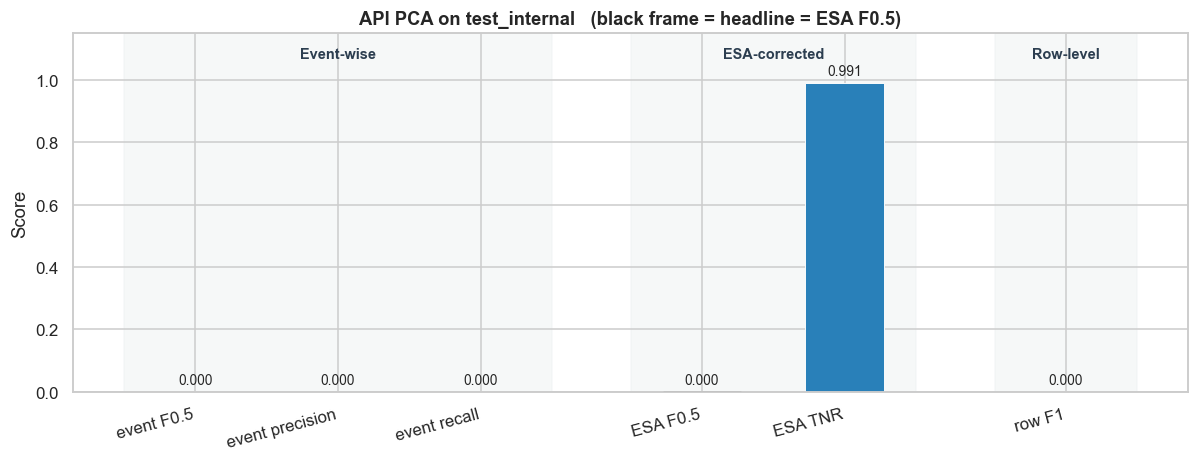

In [43]:
# Grouped bar chart - same style as nb21
BAR_GROUPS = [
    ('Event-wise',    ['event F0.5', 'event precision', 'event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['row F1']),
]
TUNE_LABEL = 'ESA F0.5'   # what we'd tune on if we did tune

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.55, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, group_labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in group_labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs = np.asarray(xs)
vals = [m[l] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8     if l == TUNE_LABEL else 0.6     for l in xlabels]
b = ax.bar(xs, vals, w, color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b, fmt='%.3f', fontsize=9, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo+xhi)/2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'API PCA on test_internal   (black frame = headline = {TUNE_LABEL})', fontweight='bold')
fig.tight_layout(); plt.show()


## 5 - Timeline

Top: per-row reconstruction MSE with the API threshold (red dashed) and
true-anomaly bands shaded behind it. Bottom: predicted-event ribbon
split into TPs (green) vs FPs (lavender). `log_y` spreads small events
that would otherwise be flattened by the largest spike.


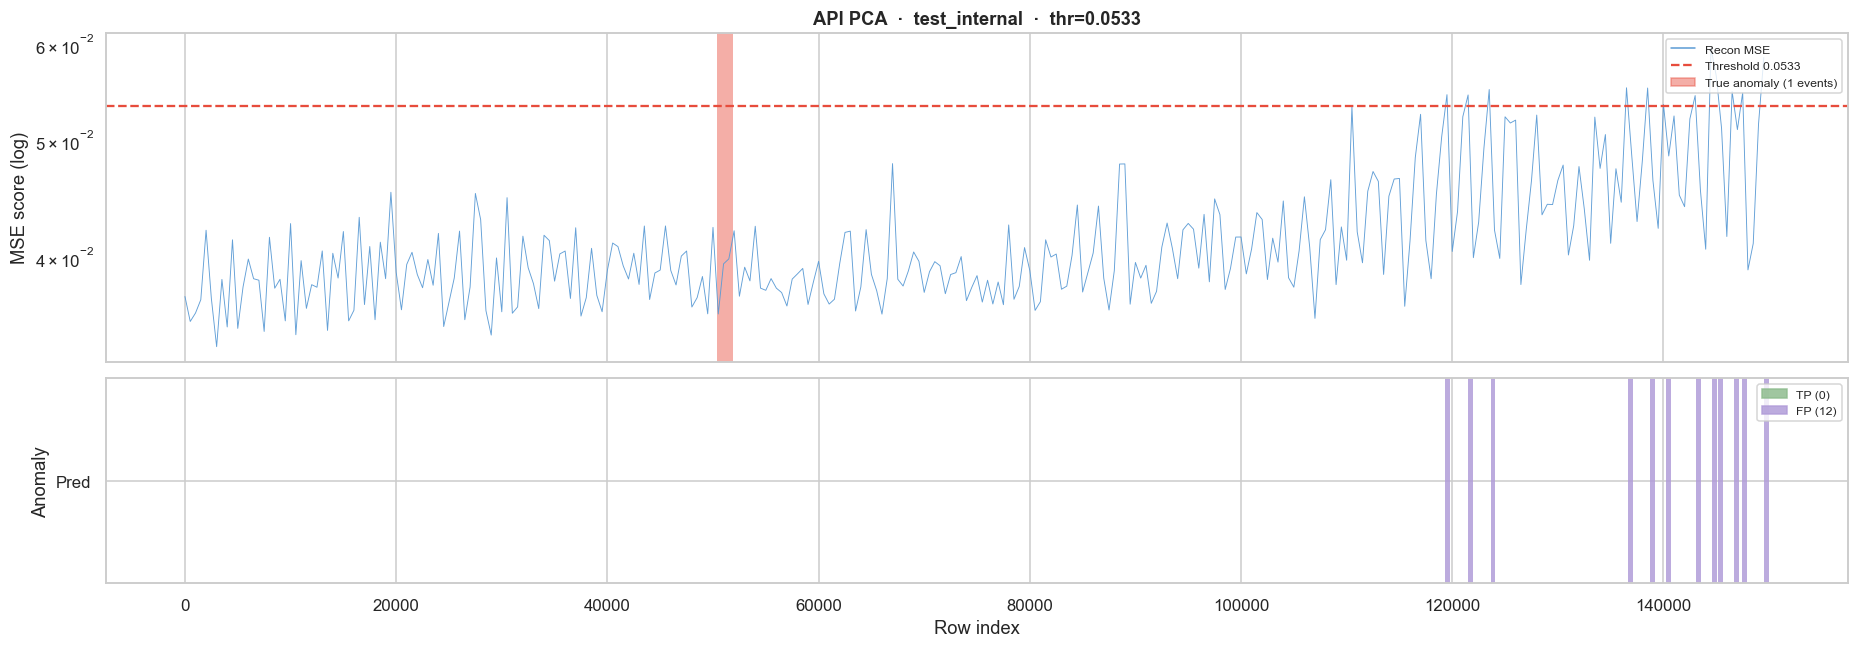

In [44]:
fig = plot_timeline(
    scores=row_scores, y_true=y_int, threshold=PCA_THRESHOLD,
    title=f'API PCA  ·  test_internal  ·  thr={PCA_THRESHOLD:.4f}',
    log_y=True,
    ## index=True,  # show row indices on x-axis
)
plt.show()


## 6 - Event analysis

Three-panel diagnostic per event:
1. Detected vs missed counts.
2. Coverage (fraction of event rows flagged) vs event length.
3. Hit-rate distribution.

Followed by the table of missed events (start / end / length) so it's
clear which segments the API model can't catch.


Missed events:
 start   end  length
 50398 51877    1480


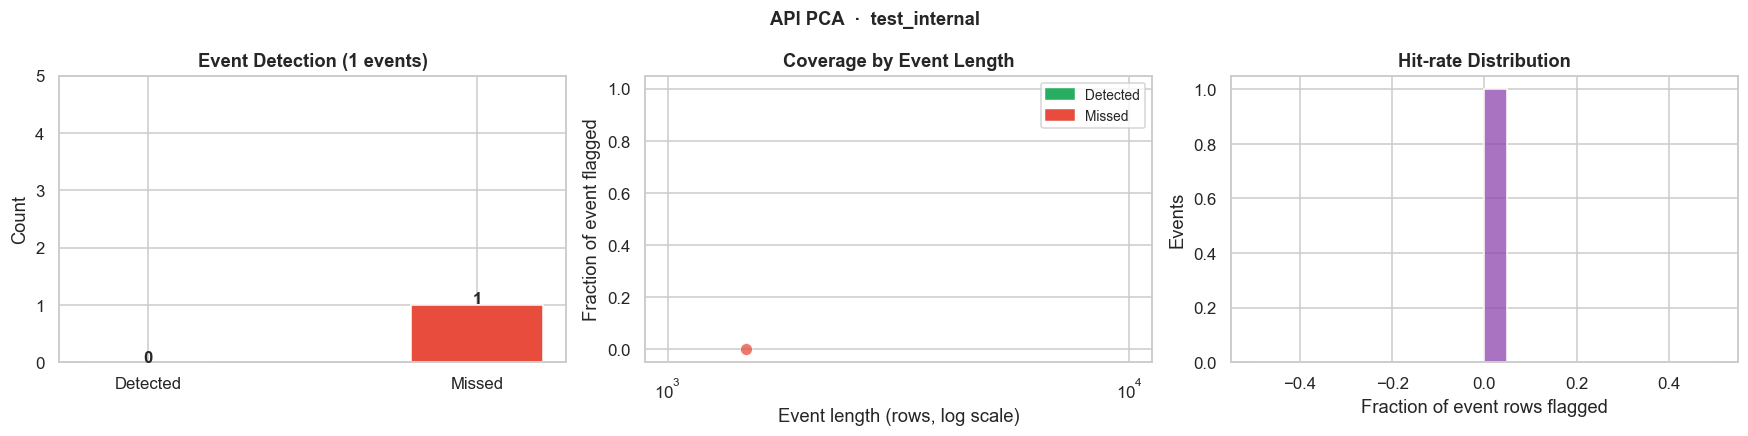

In [45]:
_ = plot_event_analysis(y_int, labels, title='API PCA  ·  test_internal')
plt.show()


## 7 - Score distribution & row-level diagnostics

* **Score histogram by class (window-level)** - one score per non-overlapping
  100-row window, labelled anomalous if it contains any anomaly row. Plotting
  at window level (not row level) is correct because PCA scores the window;
  row scores are just the window MSE broadcast, so a row-level histogram
  blends contaminated windows into both classes and exaggerates overlap.
* **Confusion matrix + per-channel MSE** - row-level confusion plus the
  top channels by mean reconstruction error. Channels driving the score
  surface here.


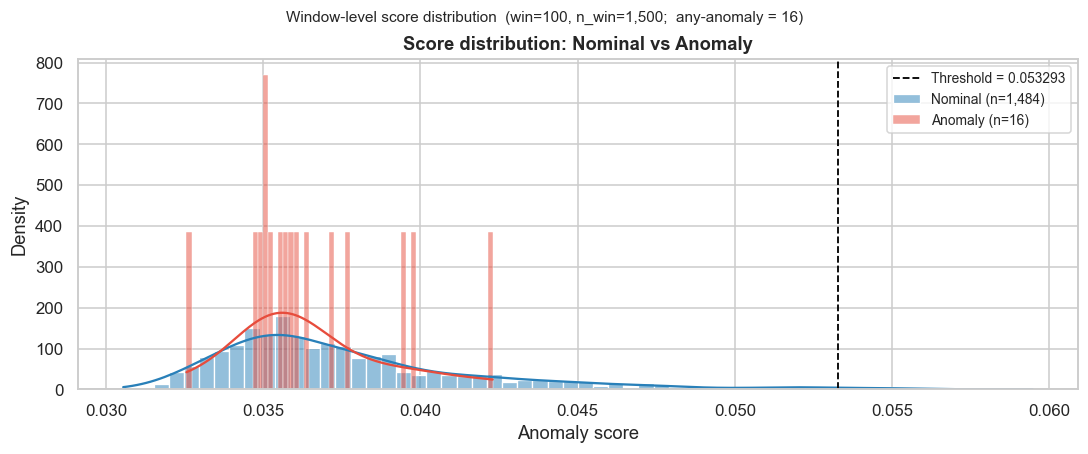

In [46]:
# Score distribution at WINDOW level (the unit the model actually decides on).
# row_scores are window-mean MSE broadcast to all 100 rows in the window - plotting
# them by row-label mixes contaminated windows into both classes. We collapse to
# one score per window and label a window anomalous if any of its rows are.
from sentinel.params import WINDOW_SIZE as WIN

n_win      = len(row_scores) // WIN
win_scores = row_scores[:n_win * WIN].reshape(n_win, WIN)[:, 0]          # constant within window
win_label  = y_int[:n_win * WIN].reshape(n_win, WIN).any(axis=1).astype("int8")

fig = plot_score_distribution(win_scores, win_label, threshold=PCA_THRESHOLD)
fig.suptitle(
    f"Window-level score distribution  (win={WIN}, "
    f"n_win={n_win:,};  any-anomaly = {int(win_label.sum()):,})",
    y=1.02, fontsize=10,
)
plt.show()


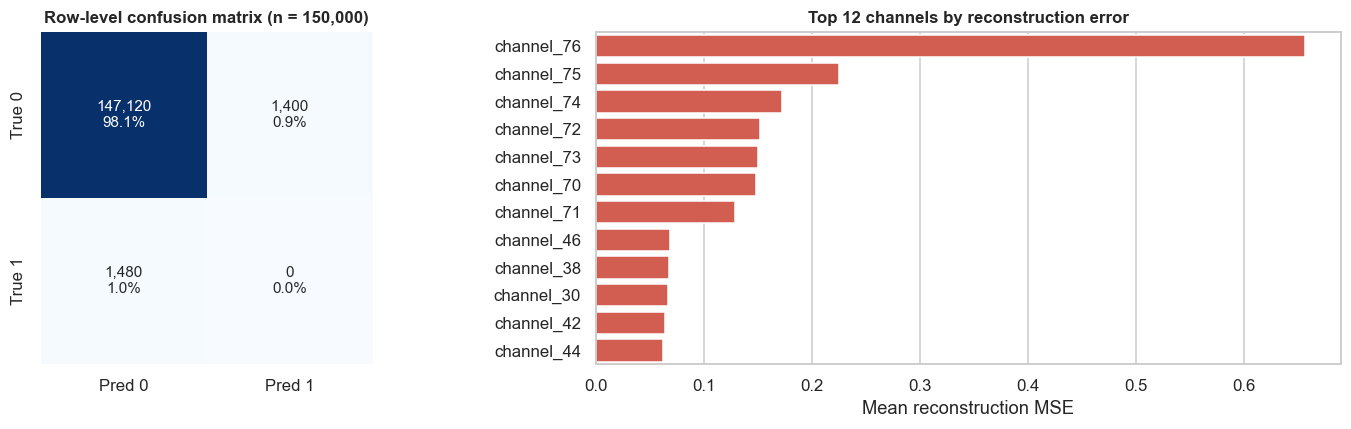

In [47]:
fig = plot_confusion_and_channel_errors(
    y_true=y_int, y_pred=labels,
    per_channel_mse=per_channel_mse,
    channel_names=features,
    top_k=12,
)
plt.show()


## 8 - Top-N channel frequency

`predict_report(n_top_channels=6)` returns, for every window, the indices
of the 6 channels with the largest reconstruction error (ranked
descending by per-channel MSE). Counting how often each channel shows up
in that top-6 tells us which channels are the *primary suspects* across
the slice - useful for explaining a flagged window to an operator (which
channel triggered it).

`n_top_channels` controls only this diagnostic; the score reduction
still uses the PCA default (mean over all channels). The `topk`
parameter is reserved for LSTM-style score reduction.


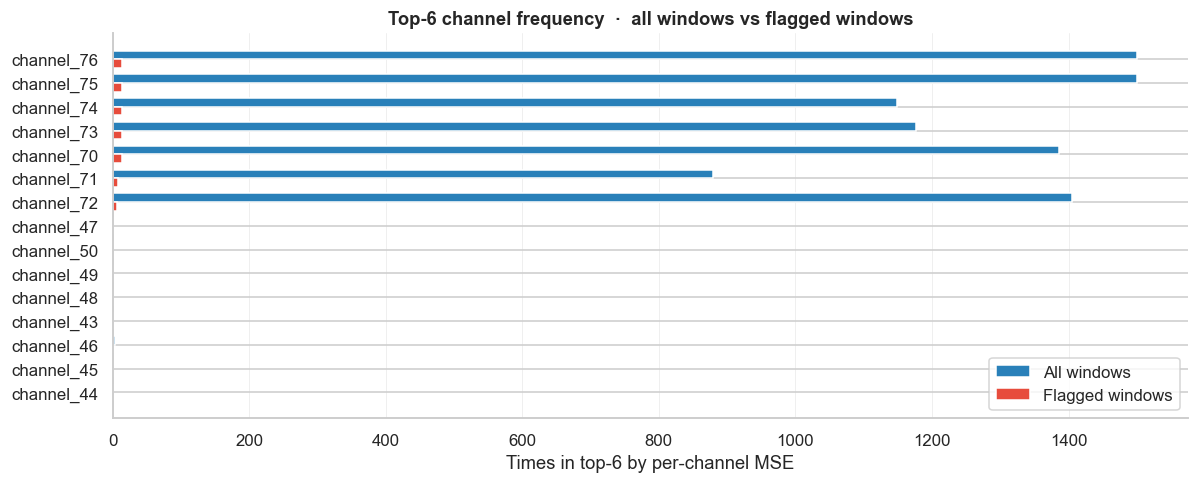


Total windows: 1,500   ·   flagged: 14 (0.93%)


In [48]:
# Frequency over windows where the model flagged anomaly only
from sentinel.ml_logic.scorer import broadcast_window_scores_to_rows

# Reconstruct window-level prediction from row labels: a window is flagged
# if its centre row is flagged. Cheap proxy: take window_scores > threshold.
win_scores = rep['window_scores']
win_pred   = (win_scores > PCA_THRESHOLD).astype(np.int8)

freq_all     = np.bincount(window_top_channels.ravel(), minlength=len(features))
freq_flagged = np.bincount(window_top_channels[win_pred == 1].ravel(), minlength=len(features)) \
               if win_pred.any() else np.zeros(len(features), dtype=int)

df_top = pd.DataFrame({
    'channel'   : features,
    'all_wins'  : freq_all,
    'flagged'   : freq_flagged,
}).sort_values('flagged', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(df_top))
ax.barh(y - 0.18, df_top['all_wins'],  0.36, color=NOMINAL_COLOR, label='All windows', edgecolor='white')
ax.barh(y + 0.18, df_top['flagged'],   0.36, color=ANOMALY_COLOR, label='Flagged windows', edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels(df_top['channel'])
ax.invert_yaxis()
ax.set_xlabel('Times in top-6 by per-channel MSE')
ax.set_title('Top-6 channel frequency  ·  all windows vs flagged windows', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, axis='x', color='#eeeeee', lw=0.6, zorder=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.show()

print(f'\nTotal windows: {len(win_scores):,}   ·   flagged: {int(win_pred.sum()):,} ({win_pred.mean():.2%})')


# API /report

### Frontend visualisations - built from the `/report` payload

The next three cells reproduce **exactly** what a frontend gets when it
calls `GET /report`: we run `predict_report()` on `test_api.npy` (the
slice the live API actually serves) and assemble the same dict the
endpoint returns. Then we render the three views a stakeholder UI would
build on top of it.

In [49]:
# Mirror the FastAPI lifespan: load test_api.npy and call predict_report().
# n_top_channels=6 -> diagnostic only (fills 'window_top_channels' output).
# Scoring stays at PCA default (topk=None, mean over all channels) so it
# matches /timeline.
X_api = np.load(PROCESSED_DIR / 'test_api.npy')
y_api = np.load(PROCESSED_DIR / 'y_test_api.npy')   # only for sanity, NOT in payload

rep_api = predict_report(
    model=model, scaler=scaler, features=features,
    X_raw=X_api, threshold=PCA_THRESHOLD,
    n_top_channels=6,
)

# Assemble the same dict that fast.py stores in app.state.report
report_payload = {
    'row_scores'         : rep_api['row_scores'].tolist(),
    # per-channel reconstruction error (MSE), sortable by most contributing
    # channel for anomaly detection
    'per_channel_mse'    : [
        {'channel': ch, 'mse': float(mse)}
        for ch, mse in zip(rep_api['features'], rep_api['per_channel_mse'])
    ],
    # indices of the n_top_channels with the largest MSE PER WINDOW, ranked descending
    'window_top_channels': rep_api['window_top_channels'].tolist(),
    'threshold'          : float(rep_api['threshold']),
    'features'           : list(rep_api['features']),
    'n_anomalies'        : int((rep_api['labels'] == 1).sum()),
    'anomaly_rate'       : round(float(rep_api['labels'].mean()), 4),
}
print(f"X_api               : {X_api.shape}   {X_api.dtype}")
print(f"row_scores          : len={len(report_payload['row_scores']):,}")
print(f"per_channel_mse     : {len(report_payload['per_channel_mse'])} entries  (e.g. {report_payload['per_channel_mse'][0]})")
print(f"window_top_channels : {len(report_payload['window_top_channels'])} windows × {len(report_payload['window_top_channels'][0])}")
print(f"threshold           : {report_payload['threshold']}")
print(f"n_anomalies         : {report_payload['n_anomalies']:,}")
print(f"anomaly_rate        : {report_payload['anomaly_rate']:.2%}")

X_api               : (150000, 58)   float32
row_scores          : len=150,000
per_channel_mse     : 58 entries  (e.g. {'channel': 'channel_12', 'mse': 0.0014585492899641395})
window_top_channels : 1500 windows × 6
threshold           : 0.053293
n_anomalies         : 1,400
anomaly_rate        : 0.93%


**Anomaly-score timeline.** The frontend's main panel: a
line plot of `row_scores` with the API threshold as a dashed line and
red shading where the score crosses it. Built **only** from
`row_scores` and `threshold` - no labels needed.

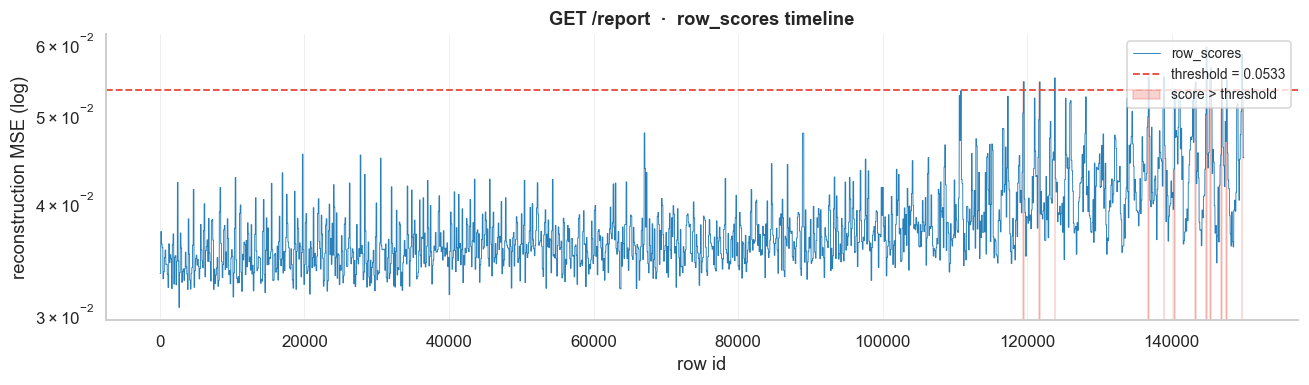

In [50]:
# row_scores timeline with threshold line and anomaly shading
row_scores_api = np.asarray(report_payload['row_scores'])
thr            = report_payload['threshold']
above          = row_scores_api > thr

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(row_scores_api, color=NOMINAL_COLOR, lw=0.6, label='row_scores')
ax.axhline(thr, color=ANOMALY_COLOR, ls='--', lw=1.2, label=f'threshold = {thr:.4f}')
ax.fill_between(np.arange(len(row_scores_api)), 0, row_scores_api,
                where=above, color=ANOMALY_COLOR, alpha=0.25, step='mid',
                label='score > threshold')
ax.set_yscale('log')
ax.set_xlabel('row id')
ax.set_ylabel('reconstruction MSE (log)')
ax.set_title('GET /report  ·  row_scores timeline', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, color='#eeeeee', lw=0.6, zorder=0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout(); plt.show()

**Timeline overlay - predicted vs true.** `row_scores` plus the static
threshold (red dashed) plus the ground-truth event shaded. Visual answer
to "does the model flag the actual anomaly, or just the drift baseline?"

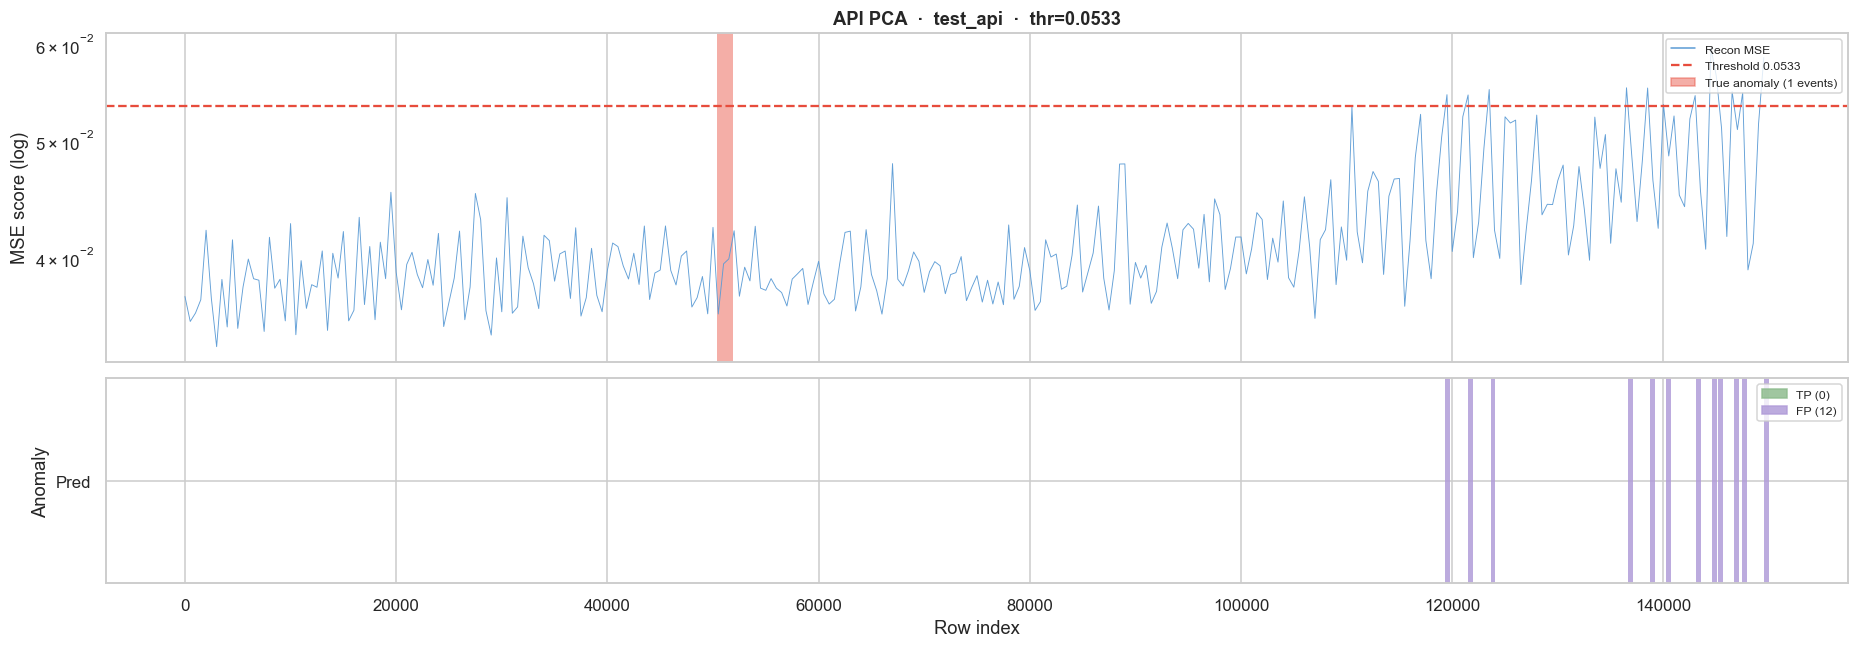

In [51]:
fig = plot_timeline(
    scores=np.asarray(report_payload['row_scores']),
    y_true=y_api,
    threshold=report_payload['threshold'],
    title=f'API PCA  ·  test_api  ·  thr={report_payload["threshold"]:.4f}',
    log_y=True,
)
plt.show()